In [1]:
# # ============================================================
# # FULL EVALUATION PIPELINE (ONE CELL)
# # JSON SPLIT + DATASET + PREDICTOR + ALL METRICS
# # ============================================================

# !pip install pycocotools -q

# import os, json, torch, numpy as np
# from PIL import Image, ImageDraw
# from tqdm import tqdm

# from torch.utils.data import Dataset, DataLoader
# from torchvision.models.detection import maskrcnn_resnet50_fpn
# from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
# from pycocotools.coco import COCO
# from pycocotools.cocoeval import COCOeval

# # ============================================================
# # PATHS (EDIT THESE)
# # ============================================================
# SPLIT_JSON = "/kaggle/input/datasets/saheemreshi/maskrcnn-models-and-datasplit-json/data_split.json"
# BASE_PATH  = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"
# /kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed

# IMAGES_DIR = os.path.join(BASE_PATH, "train/images")
# ANNOS_DIR  = os.path.join(BASE_PATH, "train/annos")

# SCRATCH_MODEL  = "/kaggle/working/maskrcnn_scratch_best.pth"
# TRANSFER_MODEL = "/kaggle/working/maskrcnn_best.pth"

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # ============================================================
# # LOAD SPLIT
# # ============================================================
# with open(SPLIT_JSON) as f:
#     split = json.load(f)

# val_files = [f.replace(".jpg", ".json") for f in split["val"]]

# # ============================================================
# # DATASET
# # ============================================================
# class DatasetMaskRCNN(Dataset):
#     def __init__(self, img_dir, anno_dir, files):
#         self.img_dir = img_dir
#         self.anno_dir = anno_dir
#         self.files = files

#         self.label_map = {
#             "short sleeve top": 1,
#             "trousers": 2,
#             "shorts": 3,
#             "long sleeve top": 4,
#             "skirt": 5
#         }

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         file = self.files[idx]

#         img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))
#         json_path = os.path.join(self.anno_dir, file)

#         image = Image.open(img_path).convert("RGB")
#         image = image.resize((512, 512))
#         w, h = image.size

#         with open(json_path) as f:
#             data = json.load(f)

#         boxes, labels, masks = [], [], []

#         for k, v in data.items():
#             if not k.startswith("item"):
#                 continue

#             cat = v["category_name"]
#             if cat not in self.label_map:
#                 continue

#             boxes.append(v["bounding_box"])
#             labels.append(self.label_map[cat])

#             mask = Image.new("L", (w, h), 0)
#             for poly in v["segmentation"]:
#                 if len(poly) >= 6:
#                     ImageDraw.Draw(mask).polygon(poly, outline=1, fill=1)

#             mask = mask.resize((512, 512))
#             masks.append(np.array(mask))

#         if len(boxes) == 0:
#             return self.__getitem__((idx + 1) % len(self))

#         image = np.array(image).transpose(2,0,1)
#         image = torch.tensor(image, dtype=torch.float32) / 255.0

#         target = {
#             "boxes": torch.tensor(boxes, dtype=torch.float32),
#             "labels": torch.tensor(labels),
#             "masks": torch.tensor(np.array(masks), dtype=torch.uint8)
#         }

#         return image, target


# def collate_fn(batch):
#     return tuple(zip(*batch))


# val_dataset = DatasetMaskRCNN(IMAGES_DIR, ANNOS_DIR, val_files)
# val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

# # ============================================================
# # MODEL + PREDICTOR
# # ============================================================
# NUM_CLASSES = 6

# def load_model(path):
#     model = maskrcnn_resnet50_fpn(pretrained=False)

#     in_features = model.roi_heads.box_predictor.cls_score.in_features
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

#     in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
#     model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)

#     model.load_state_dict(torch.load(path, map_location=DEVICE))
#     model.to(DEVICE)
#     model.eval()
#     return model


# class Predictor:
#     def __init__(self, path):
#         self.model = load_model(path)

#     def predict(self, images):
#         images = [img.to(DEVICE) for img in images]
#         with torch.no_grad():
#             outputs = self.model(images)

#         res = []
#         for o in outputs:
#             res.append({
#                 "boxes": o["boxes"].cpu().numpy(),
#                 "labels": o["labels"].cpu().numpy(),
#                 "scores": o["scores"].cpu().numpy(),
#                 "masks": (o["masks"] > 0.5).squeeze(1).cpu().numpy()
#             })
#         return res

# # ============================================================
# # METRICS HELPERS
# # ============================================================
# def compute_iou(a, b):
#     x1=max(a[0],b[0]); y1=max(a[1],b[1])
#     x2=min(a[2],b[2]); y2=min(a[3],b[3])
#     inter=max(0,x2-x1)*max(0,y2-y1)
#     A=(a[2]-a[0])*(a[3]-a[1])
#     B=(b[2]-b[0])*(b[3]-b[1])
#     return inter/(A+B-inter+1e-6)

# def match(pred, gt, thr=0.5):
#     matches=[]; used=set()
#     for i,pb in enumerate(pred["boxes"]):
#         best=0; idx=-1
#         for j,gb in enumerate(gt["boxes"].numpy()):
#             if j in used: continue
#             iou=compute_iou(pb,gb)
#             if iou>best:
#                 best=iou; idx=j
#         if best>=thr:
#             matches.append((i,idx))
#             used.add(idx)
#     return matches

# def mask_metrics(p,g):
#     inter=np.logical_and(p,g).sum()
#     union=np.logical_or(p,g).sum()
#     iou=inter/(union+1e-6)
#     dice=2*inter/(p.sum()+g.sum()+1e-6)
#     return iou,dice

# # ============================================================
# # COCO BUILD
# # ============================================================
# def build_coco_gt(loader):
#     images=[]; anns=[]; ann_id=1
#     cats=[{"id":i,"name":str(i)} for i in range(1,6)]

#     img_id=0
#     for _,targets in loader:
#         for t in targets:
#             images.append({"id":img_id,"width":512,"height":512})
#             for b,l in zip(t["boxes"],t["labels"]):
#                 x1,y1,x2,y2=b.numpy()
#                 w=x2-x1; h=y2-y1
#                 anns.append({
#                     "id":ann_id,"image_id":img_id,"category_id":int(l),
#                     "bbox":[x1,y1,w,h],"area":w*h,"iscrowd":0
#                 })
#                 ann_id+=1
#             img_id+=1

#     coco=COCO()
#     coco.dataset={"images":images,"annotations":anns,"categories":cats}
#     coco.createIndex()
#     return coco

# def build_coco_pred(predictor, loader):
#     res=[]; img_id=0
#     for imgs,_ in tqdm(loader):
#         outs=predictor.predict(imgs)
#         for o in outs:
#             for b,l,s in zip(o["boxes"],o["labels"],o["scores"]):
#                 x1,y1,x2,y2=b
#                 res.append({
#                     "image_id":img_id,
#                     "category_id":int(l),
#                     "bbox":[x1,y1,x2-x1,y2-y1],
#                     "score":float(s)
#                 })
#             img_id+=1
#     return res

# # ============================================================
# # MAIN EVAL
# # ============================================================
# def evaluate(model_path):

#     predictor = Predictor(model_path)

#     gt_cls=[]; pred_cls=[]; scores=[]
#     seg_iou=[[] for _ in range(6)]
#     seg_dice=[[] for _ in range(6)]

#     for imgs,targets in tqdm(val_loader):
#         outs=predictor.predict(imgs)

#         for p,g in zip(outs,targets):
#             matches=match(p,g)

#             for pi,gi in matches:
#                 gt_cls.append(g["labels"][gi].item())
#                 pred_cls.append(p["labels"][pi])
#                 scores.append(p["scores"][pi])

#                 pm=p["masks"][pi]
#                 gm=g["masks"][gi].numpy()

#                 iou,dice=mask_metrics(pm,gm)
#                 cls=g["labels"][gi].item()

#                 seg_iou[cls].append(iou)
#                 seg_dice[cls].append(dice)

#     # CLASSIFICATION
#     prec,rec,f1,_=precision_recall_fscore_support(gt_cls,pred_cls,average=None,zero_division=0)
#     macro_f1=np.mean(f1)
#     _,_,micro_f1,_=precision_recall_fscore_support(gt_cls,pred_cls,average="micro")

#     print("\nCLASSIFICATION")
#     print("Precision:",prec)
#     print("Recall:",rec)
#     print("F1:",f1)
#     print("Macro F1:",macro_f1)
#     print("Micro F1:",micro_f1)

#     # ROC
#     print("\nROC AUC")
#     for c in range(1,6):
#         y_true=[1 if g==c else 0 for g in gt_cls]
#         if len(set(y_true))<2: continue
#         fpr,tpr,_=roc_curve(y_true,scores)
#         print(f"Class {c} AUC:",auc(fpr,tpr))

#     # SEGMENTATION
#     miou=[np.mean(x) if x else 0 for x in seg_iou]
#     dice=[np.mean(x) if x else 0 for x in seg_dice]

#     print("\nSEGMENTATION")
#     print("mIoU:",miou,"Mean:",np.mean(miou))
#     print("Dice:",dice,"Mean:",np.mean(dice))

#     # COCO mAP
#     print("\nCOCO mAP")
#     coco_gt=build_coco_gt(val_loader)
#     coco_pred=build_coco_pred(predictor,val_loader)

#     coco_dt=coco_gt.loadRes(coco_pred)
#     eval=COCOeval(coco_gt,coco_dt,"bbox")
#     eval.evaluate(); eval.accumulate(); eval.summarize()


# # ============================================================
# # RUN BOTH MODELS
# # ============================================================
# print("\n===== SCRATCH =====")
# evaluate(SCRATCH_MODEL)

# print("\n===== TRANSFER =====")
# evaluate(TRANSFER_MODEL)


===== SCRATCH =====


100%|██████████| 2163/2163 [09:15<00:00,  3.89it/s]



===== CLASSIFICATION =====

Class: short sleeve top
  Precision: 0.7880
  Recall:    0.7382
  F1-score:  0.7623

Class: trousers
  Precision: 0.6610
  Recall:    0.8333
  F1-score:  0.7372

Class: shorts
  Precision: 0.5039
  Recall:    0.5000
  F1-score:  0.5019

Class: long sleeve top
  Precision: 0.6104
  Recall:    0.4444
  F1-score:  0.5144

Class: skirt
  Precision: 0.3858
  Recall:    0.6561
  F1-score:  0.4858

Macro F1: 0.6003366919921478
Micro F1: 0.6578512396694215

===== ROC CURVES =====
short sleeve top AUC: 0.8131
trousers AUC: 0.9018
shorts AUC: 0.7384
long sleeve top AUC: 0.6906
skirt AUC: 0.7926


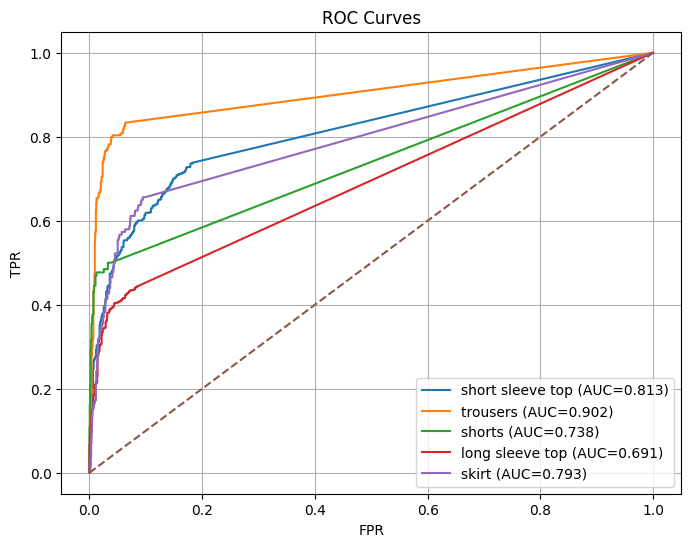


===== SEGMENTATION =====
short sleeve top → mIoU: 0.5669, Dice: 0.7114
trousers → mIoU: 0.5271, Dice: 0.6789
shorts → mIoU: 0.5243, Dice: 0.6766
long sleeve top → mIoU: 0.5692, Dice: 0.7119
skirt → mIoU: 0.5387, Dice: 0.6903

Mean mIoU: 0.45437713931379003
Mean Dice: 0.5781836148861043

===== COCO mAP =====
creating index...
index created!


100%|██████████| 2163/2163 [08:17<00:00,  4.35it/s]


Loading and preparing results...
DONE (t=0.31s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.01s).
Accumulating evaluation results...
DONE (t=1.50s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.033
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.055
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.062
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.062
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

100%|██████████| 2163/2163 [08:06<00:00,  4.44it/s]



===== CLASSIFICATION =====

Class: short sleeve top
  Precision: 0.7796
  Recall:    0.7364
  F1-score:  0.7574

Class: trousers
  Precision: 0.5820
  Recall:    0.8838
  F1-score:  0.7018

Class: shorts
  Precision: 0.5473
  Recall:    0.5159
  F1-score:  0.5311

Class: long sleeve top
  Precision: 0.5768
  Recall:    0.4777
  F1-score:  0.5226

Class: skirt
  Precision: 0.5132
  Recall:    0.5543
  F1-score:  0.5330

Macro F1: 0.6091823474694186
Micro F1: 0.6621143146181082

===== ROC CURVES =====
short sleeve top AUC: 0.8003
trousers AUC: 0.9260
shorts AUC: 0.7455
long sleeve top AUC: 0.7009
skirt AUC: 0.7582


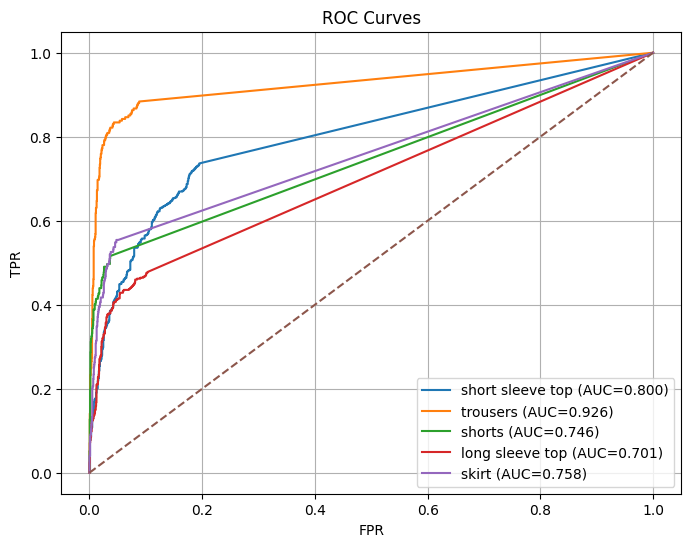


===== SEGMENTATION =====
short sleeve top → mIoU: 0.5528, Dice: 0.6980
trousers → mIoU: 0.5254, Dice: 0.6769
shorts → mIoU: 0.4983, Dice: 0.6491
long sleeve top → mIoU: 0.5667, Dice: 0.7088
skirt → mIoU: 0.5294, Dice: 0.6796

Mean mIoU: 0.44542299384762246
Mean Dice: 0.5687388750945538

===== COCO mAP =====
creating index...
index created!


100%|██████████| 2163/2163 [07:56<00:00,  4.54it/s]


Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.44s).
Accumulating evaluation results...
DONE (t=1.35s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.064
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.072
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.072
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

In [2]:
# ============================================================
# FULL FINAL EVALUATION PIPELINE (SUBMISSION READY)
# ============================================================

!pip install pycocotools -q

import os, json, torch, numpy as np
from PIL import Image, ImageDraw
from tqdm import tqdm
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ============================================================
# PATHS
# ============================================================
SPLIT_JSON = "/kaggle/input/datasets/saheemreshi/maskrcnn-models-and-datasplit-json/data_split.json"
BASE_PATH  = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

IMAGES_DIR = os.path.join(BASE_PATH, "train/images")
ANNOS_DIR  = os.path.join(BASE_PATH, "train/annos")

SCRATCH_MODEL  = "/kaggle/input/datasets/saheemreshi/maskrcnn-models-and-datasplit-json/maskrcnn_scratch.pth"
TRANSFER_MODEL = "/kaggle/input/datasets/saheemreshi/maskrcnn-models-and-datasplit-json/MaskRCNNTransfer.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# CLASS NAMES
# ============================================================
CLASS_NAMES = [
    "background",
    "short sleeve top",
    "trousers",
    "shorts",
    "long sleeve top",
    "skirt"
]

# ============================================================
# LOAD SPLIT
# ============================================================
with open(SPLIT_JSON) as f:
    split = json.load(f)

val_files = [f.replace(".jpg", ".json") for f in split["test"]]

# ============================================================
# DATASET
# ============================================================
class DatasetMaskRCNN(Dataset):
    def __init__(self, img_dir, anno_dir, files):
        self.img_dir = img_dir
        self.anno_dir = anno_dir
        self.files = files

        self.label_map = {
            "short sleeve top": 1,
            "trousers": 2,
            "shorts": 3,
            "long sleeve top": 4,
            "skirt": 5
        }

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]

        img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))
        json_path = os.path.join(self.anno_dir, file)

        image = Image.open(img_path).convert("RGB")
        image = image.resize((512, 512))
        w, h = image.size

        with open(json_path) as f:
            data = json.load(f)

        boxes, labels, masks = [], [], []

        for k, v in data.items():
            if not k.startswith("item"):
                continue

            cat = v["category_name"]
            if cat not in self.label_map:
                continue

            boxes.append(v["bounding_box"])
            labels.append(self.label_map[cat])

            mask = Image.new("L", (w, h), 0)
            for poly in v["segmentation"]:
                if len(poly) >= 6:
                    ImageDraw.Draw(mask).polygon(poly, outline=1, fill=1)

            mask = mask.resize((512, 512))
            masks.append(np.array(mask))

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self))

        image = np.array(image).transpose(2,0,1)
        image = torch.tensor(image, dtype=torch.float32) / 255.0

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels),
            "masks": torch.tensor(np.array(masks), dtype=torch.uint8)
        }

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


val_dataset = DatasetMaskRCNN(IMAGES_DIR, ANNOS_DIR, val_files)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

# ============================================================
# MODEL
# ============================================================
NUM_CLASSES = 6

def load_model(path):

    model = maskrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, NUM_CLASSES)

    model.load_state_dict(torch.load(path, map_location=DEVICE))

    # if torch.cuda.device_count() > 1:
    #     print("Using", torch.cuda.device_count(), "GPUs")
    #     model = torch.nn.DataParallel(model)

    model.to(DEVICE)
    model.eval()
    return model


class Predictor:
    def __init__(self, path):
        self.model = load_model(path)

    def predict(self, images):
        images = [img.to(DEVICE) for img in images]
        with torch.no_grad():
            outputs = self.model(images)

        res = []
        for o in outputs:
            res.append({
                "boxes": o["boxes"].cpu().numpy(),
                "labels": o["labels"].cpu().numpy(),
                "scores": o["scores"].cpu().numpy(),
                "masks": (o["masks"] > 0.5).squeeze(1).cpu().numpy()
            })
        return res

# ============================================================
# HELPERS
# ============================================================
def compute_iou(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    A=(a[2]-a[0])*(a[3]-a[1])
    B=(b[2]-b[0])*(b[3]-b[1])
    return inter/(A+B-inter+1e-6)

def match(pred, gt, thr=0.5):
    matches=[]; used=set()
    for i,pb in enumerate(pred["boxes"]):
        best=0; idx=-1
        for j,gb in enumerate(gt["boxes"].numpy()):
            if j in used: continue
            iou=compute_iou(pb,gb)
            if iou>best:
                best=iou; idx=j
        if best>=thr:
            matches.append((i,idx))
            used.add(idx)
    return matches

def mask_metrics(p,g):
    inter=np.logical_and(p,g).sum()
    union=np.logical_or(p,g).sum()
    iou=inter/(union+1e-6)
    dice=2*inter/(p.sum()+g.sum()+1e-6)
    return iou,dice

# ============================================================
# COCO
# ============================================================
def build_coco_gt(loader):
    images=[]; anns=[]; ann_id=1
    cats=[{"id":i,"name":str(i)} for i in range(1,6)]

    img_id=0
    for _,targets in loader:
        for t in targets:
            images.append({"id":img_id,"width":512,"height":512})
            for b,l in zip(t["boxes"],t["labels"]):
                x1,y1,x2,y2=b.numpy()
                w=x2-x1; h=y2-y1
                anns.append({
                    "id":ann_id,"image_id":img_id,"category_id":int(l),
                    "bbox":[x1,y1,w,h],"area":w*h,"iscrowd":0
                })
                ann_id+=1
            img_id+=1

    coco=COCO()
    coco.dataset={"images":images,"annotations":anns,"categories":cats}
    coco.createIndex()
    return coco

def build_coco_pred(predictor, loader):
    res=[]; img_id=0
    for imgs,_ in tqdm(loader):
        outs=predictor.predict(imgs)
        for o in outs:
            for b,l,s in zip(o["boxes"],o["labels"],o["scores"]):
                x1,y1,x2,y2=b
                res.append({
                    "image_id":img_id,
                    "category_id":int(l),
                    "bbox":[x1,y1,x2-x1,y2-y1],
                    "score":float(s)
                })
            img_id+=1
    return res

# ============================================================
# EVALUATION
# ============================================================
def evaluate(model_path):

    predictor = Predictor(model_path)

    gt_cls=[]; pred_cls=[]; scores=[]
    seg_iou=[[] for _ in range(6)]
    seg_dice=[[] for _ in range(6)]

    for imgs,targets in tqdm(val_loader):
        outs=predictor.predict(imgs)

        for p,g in zip(outs,targets):
            matches=match(p,g)

            for pi,gi in matches:
                gt_cls.append(g["labels"][gi].item())
                pred_cls.append(p["labels"][pi])
                scores.append(p["scores"][pi])

                pm=p["masks"][pi]
                gm=g["masks"][gi].numpy()

                iou,dice=mask_metrics(pm,gm)
                cls=g["labels"][gi].item()

                seg_iou[cls].append(iou)
                seg_dice[cls].append(dice)

    # =====================
    # CLASSIFICATION
    # =====================
    prec, rec, f1, _ = precision_recall_fscore_support(
        gt_cls, pred_cls,
        labels=[1,2,3,4,5],
        zero_division=0
    )

    macro_f1 = np.mean(f1)
    _, _, micro_f1, _ = precision_recall_fscore_support(gt_cls, pred_cls, average="micro")

    print("\n===== CLASSIFICATION =====")

    for i in range(5):
        print(f"\nClass: {CLASS_NAMES[i+1]}")
        print(f"  Precision: {prec[i]:.4f}")
        print(f"  Recall:    {rec[i]:.4f}")
        print(f"  F1-score:  {f1[i]:.4f}")

    print("\nMacro F1:", macro_f1)
    print("Micro F1:", micro_f1)

    # =====================
    # ROC CURVES
    # =====================
    print("\n===== ROC CURVES =====")

    plt.figure(figsize=(8,6))

    for c in range(1,6):
        y_true = [1 if g==c else 0 for g in gt_cls]
        if len(set(y_true)) < 2:
            continue

        y_scores = [s if pred_cls[i]==c else 0 for i,s in enumerate(scores)]

        fpr,tpr,_ = roc_curve(y_true, y_scores)
        auc_score = auc(fpr,tpr)

        print(f"{CLASS_NAMES[c]} AUC: {auc_score:.4f}")
        plt.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={auc_score:.3f})")

    plt.plot([0,1],[0,1],'--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid()
    plt.savefig("roc_curve.png")
    plt.show()

    # =====================
    # SEGMENTATION
    # =====================
    miou=[np.mean(x) if x else 0 for x in seg_iou]
    dice=[np.mean(x) if x else 0 for x in seg_dice]

    print("\n===== SEGMENTATION =====")
    for i in range(1,6):
        print(f"{CLASS_NAMES[i]} → mIoU: {miou[i]:.4f}, Dice: {dice[i]:.4f}")

    print("\nMean mIoU:", np.mean(miou))
    print("Mean Dice:", np.mean(dice))

    # =====================
    # COCO mAP
    # =====================
    print("\n===== COCO mAP =====")

    coco_gt = build_coco_gt(val_loader)
    coco_pred = build_coco_pred(predictor, val_loader)

    coco_dt = coco_gt.loadRes(coco_pred)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

# ============================================================
# RUN
# ============================================================
print("\n===== SCRATCH =====")
evaluate(SCRATCH_MODEL)

print("\n===== TRANSFER =====")
evaluate(TRANSFER_MODEL)